## Data-driven EIT Reconstruction — LOPO Cross-Validation

**Leave-One-Patient-Out (LOPO-CV)** on patients from 7 clinical studies
(RIBS, IRESP, ISUPPORT, FLOWTRIAL, MASHUP, REEF\_ROMA, PULSAR).

Dataset: ~5k frames per patient sampled from full recordings.

**Quality filtering** (per-recording, not per-patient):
- Recordings with MSE retention < 50% are dropped entirely
- Recordings with X-Y global correlation < 0.5 are dropped
- Remaining frames filtered individually (MSE > 50 removed)
- PT66/MASHUP excluded entirely (all 6 recordings have corr < 0.5)

Two feature sets compared:
- **v1** (208 features): calibrated transimpedances `vv = FT_A·trans_A − FT_B·trans_B`
- **v1b** (416 features): raw `[trans_A | trans_B]` — bypasses Adler calibration

In [1]:
from pathlib import Path
import csv
import gc
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler

from fasteit.reconstruction.data_prep import normalize
from fasteit.reconstruction.metrics import (
    correlation_per_frame,
    error_map,
    mse_per_frame,
    summary_metrics,
)

warnings.filterwarnings('ignore')

# Dräger-inspired EIT colormap
CMAP_EIT = LinearSegmentedColormap.from_list("draeger", [
    (0.00, (0.5, 0.0, 0.5)),
    (0.50, (0.0, 0.0, 0.0)),
    (0.80, (0.0, 0.0, 1.0)),
    (1.00, (1.0, 1.0, 1.0)),
])

SAMPLE_DIR = Path("/mnt/my_data/eit/npz/sample_5k")
METADATA_CSV = Path("/mnt/my_data/eit/recording_metadata.csv")
N_REF = 150
MSE_THRESHOLD = 50
MIN_FRAMES_WARN = 0.3  # warn if patient retains < 30% of frames after filter
fs = 50.0

# Per-recording quality filter thresholds
REC_RETENTION_MIN = 0.60   # drop recording if < 40% frames survive MSE filter
REC_CORR_MIN = 0.45        # drop recording if X-Y global correlation < 0.35

# Excluded patients: problematic in LOPO even after per-recording filter
EXCLUDE_PATIENTS = {
    14,              # RIBS — poor LOPO performance
    23,
    30,              # IRESP — low X-Y corr across all recordings
    32,              # IRESP — R²=0.17, weak X-Y corr across most recordings
    56,              # HIFIVE — low signal amplitude, mixed recording quality
    59,
    61,              # FLOWTRIAL — poor LOPO performance
    66,              # MASHUP — X-Y corr negative/near-zero on ALL recordings
    68,              # MASHUP — mixed recording quality, poor LOPO
    69,              # MASHUP — low retention + out-of-distribution signal
    75,              # PULSAR — poor LOPO performance
    76,              # PULSAR — poor LOPO performance
}


## 1. Load 67-patient dataset from pre-built NPZ

In [2]:
def normalize_per_recording(X, rec_id, n_ref=N_REF):
    """Subtractive normalisation per recording segment.

    Removes baseline offset: x_norm = x - mean(x[:n_ref]).
    Applied independently to each recording to avoid cross-recording contamination.
    """
    X_out = np.empty_like(X)
    for rid in np.unique(rec_id):
        idx = np.where(rec_id == rid)[0]
        x_seg = X[idx]
        n = min(n_ref, len(x_seg))
        X_out[idx] = x_seg - x_seg[:n].mean(axis=0)
    return X_out

# Load metadata for study/sex/mode annotations
meta_by_patient = {}
with open(METADATA_CSV) as f:
    for row in csv.DictReader(f):
        pid = int(row["patient_id"])
        if pid not in meta_by_patient:
            meta_by_patient[pid] = {
                "study": row["study"],
                "sex": row["sex"],
                "ventilation_mode": row["ventilation_mode"],
            }

# Load all patients (normalize per-recording, no filtering yet)
npz_files = sorted(SAMPLE_DIR.glob("patient_*.npz"))
print(f"Loading from {SAMPLE_DIR} (excluding {len(EXCLUDE_PATIENTS)} patients: {sorted(EXCLUDE_PATIENTS)}) ...")

X_vv_list, X_raw_list, Y_list, rec_id_list = [], [], [], []
patient_ids = []
n_excluded = 0

for npz_path in npz_files:
    data = np.load(npz_path)
    pid = int(data["patient_id"])

    if pid in EXCLUDE_PATIENTS:
        n_excluded += 1
        continue

    rec_id = data["rec_id"]

    # normalisation per-recording (each array independently)
    xvv_n = normalize_per_recording(data["X_vv"], rec_id)
    xraw_n = normalize_per_recording(data["X_raw"], rec_id)
    y_n = normalize_per_recording(data["Y"], rec_id)

    X_vv_list.append(xvv_n)
    X_raw_list.append(xraw_n)
    Y_list.append(y_n)
    rec_id_list.append(rec_id)
    patient_ids.append(pid)

n_patients_raw = len(patient_ids)
total_frames_raw = sum(x.shape[0] for x in X_vv_list)
print(f"\n  {n_patients_raw} patients loaded ({n_excluded} excluded), {total_frames_raw:,} raw frames")
print(f"  Studies: {sorted(set(meta_by_patient.get(p, {}).get('study', '?') for p in patient_ids))}")

Loading from /mnt/my_data/eit/npz/sample_5k (excluding 12 patients: [14, 23, 30, 32, 56, 59, 61, 66, 68, 69, 75, 76]) ...

  64 patients loaded (12 excluded), 317,935 raw frames
  Studies: ['FLOWTRIAL', 'IRESP', 'ISUPPORT', 'MASHUP', 'PULSAR', 'REEF_ROMA', 'RIBS']


## 1b. Per-recording quality filter

For each recording within each patient, check two criteria:
1. **MSE retention**: what fraction of frames have MSE(Y) < threshold? If < 50%, the recording baseline is corrupted → drop it entirely
2. **X-Y global correlation**: does the input signal track the output? If corr < 0.5, electrode coupling is poor → drop it

This replaces the old per-patient exclusion list. Previously, a single bad recording
would tank the patient-level correlation and cause the entire patient to be excluded.

In [3]:
# Per-recording quality filter (MSE retention + X-Y correlation)
total_recs_dropped = 0
total_frames_dropped = 0
patients_emptied = []  # patients with ALL recordings dropped
filter_log = []

for i in range(len(patient_ids)):
    pid = patient_ids[i]
    rec_id = rec_id_list[i]
    xvv, xraw, y = X_vv_list[i], X_raw_list[i], Y_list[i]

    good_mask = np.ones(len(y), dtype=bool)

    for rid in np.unique(rec_id):
        idx = np.where(rec_id == rid)[0]
        y_seg = y[idx]
        x_seg = xvv[idx]

        # Criterion 1: MSE retention
        frame_mse = np.mean(y_seg ** 2, axis=1)
        retention = (frame_mse < MSE_THRESHOLD).sum() / len(idx)

        # Criterion 2: X-Y global correlation
        gx = x_seg.sum(axis=1)
        gy = y_seg.sum(axis=1)
        if np.std(gx) > 0 and np.std(gy) > 0:
            corr = np.corrcoef(gx, gy)[0, 1]
        else:
            corr = 0.0

        drop_rec = retention < REC_RETENTION_MIN or corr < REC_CORR_MIN

        if drop_rec:
            good_mask[idx] = False
            total_recs_dropped += 1
            total_frames_dropped += len(idx)
            reason = []
            if retention < REC_RETENTION_MIN: reason.append(f"ret={retention:.0%}")
            if corr < REC_CORR_MIN: reason.append(f"corr={corr:.2f}")
            print(f"  PT{pid:02d} rec {rid}: DROPPED ({', '.join(reason)}, {len(idx)} frames)")
        else:
            # Within good recordings, still drop individual bad frames
            bad_frames = frame_mse >= MSE_THRESHOLD
            n_bad = bad_frames.sum()
            if n_bad > 0:
                good_mask[idx[bad_frames]] = False
                total_frames_dropped += n_bad

    # Apply mask
    n_kept = good_mask.sum()
    if n_kept == 0:
        patients_emptied.append(pid)

    X_vv_list[i] = xvv[good_mask]
    X_raw_list[i] = xraw[good_mask]
    Y_list[i] = y[good_mask]
    rec_id_list[i] = rec_id[good_mask]

    pct = n_kept / len(good_mask) * 100
    filter_log.append((pid, len(good_mask), n_kept, pct))

# Remove emptied patients
if patients_emptied:
    print(f"\n  Removing {len(patients_emptied)} patients with 0 frames: {patients_emptied}")
    keep = [i for i in range(len(patient_ids)) if patient_ids[i] not in patients_emptied]
    X_vv_list = [X_vv_list[i] for i in keep]
    X_raw_list = [X_raw_list[i] for i in keep]
    Y_list = [Y_list[i] for i in keep]
    rec_id_list = [rec_id_list[i] for i in keep]
    patient_ids = [patient_ids[i] for i in keep]

n_patients = len(patient_ids)
total_frames = sum(x.shape[0] for x in X_vv_list)
mem_gb = sum(x.nbytes for x in X_vv_list + X_raw_list + Y_list) / 1e9
retentions = [r[3] for r in filter_log if r[0] not in patients_emptied]
low_ret = [(p, nt, nk, pct) for p, nt, nk, pct in filter_log if pct < 50 and p not in patients_emptied]

print(f"\n  {total_recs_dropped} recordings dropped, {total_frames_dropped:,} frames removed")
print(f"  {n_patients} patients, {total_frames:,} frames after filter")
print(f"  Retention: mean={np.mean(retentions):.0f}%, min={np.min(retentions):.0f}%")
if low_ret:
    print(f"  {len(low_ret)} patients with <50% retention:")
    for pid, nt, nk, pct in low_ret:
        print(f"      PT{pid:02d}: {nk}/{nt} frames ({pct:.0f}%)")
print(f"  Memory: {mem_gb:.1f} GB")
print(f"  Studies: {sorted(set(meta_by_patient.get(p, {}).get('study', '?') for p in patient_ids))}")

  PT01 rec 0: DROPPED (ret=0%, 1792 frames)
  PT06 rec 0: DROPPED (corr=-0.09, 1753 frames)
  PT06 rec 1: DROPPED (ret=33%, 1116 frames)
  PT06 rec 2: DROPPED (ret=60%, 376 frames)
  PT07 rec 0: DROPPED (ret=48%, 1074 frames)
  PT07 rec 1: DROPPED (ret=0%, 475 frames)
  PT08 rec 0: DROPPED (ret=22%, 1811 frames)
  PT10 rec 0: DROPPED (ret=32%, 986 frames)
  PT10 rec 1: DROPPED (ret=33%, 2739 frames)
  PT10 rec 2: DROPPED (ret=43%, 1273 frames)
  PT11 rec 0: DROPPED (ret=50%, 1339 frames)
  PT15 rec 0: DROPPED (corr=0.21, 673 frames)
  PT19 rec 3: DROPPED (corr=0.36, 1489 frames)
  PT28 rec 0: DROPPED (corr=0.01, 1279 frames)
  PT28 rec 1: DROPPED (corr=0.43, 1279 frames)
  PT28 rec 2: DROPPED (corr=0.12, 1162 frames)
  PT28 rec 3: DROPPED (corr=0.14, 1279 frames)
  PT31 rec 2: DROPPED (corr=0.42, 1250 frames)
  PT34 rec 1: DROPPED (corr=-0.26, 1607 frames)
  PT34 rec 2: DROPPED (ret=40%, 1492 frames)
  PT36 rec 0: DROPPED (corr=0.22, 399 frames)
  PT36 rec 2: DROPPED (corr=0.34, 384 fr

## 2. Alpha selection via GCV

Select regularisation strength on pooled data (all 67 patients).
RidgeCV with Generalised Cross-Validation — efficient, no data leakage.

In [4]:
alpha_grid = [1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0]

# Pool a stratified subset for GCV (first 2000 frames per patient)
#X_gcv_vv = np.concatenate([x[:2000] for x in X_vv_list])
#X_gcv_raw = np.concatenate([x[:2000] for x in X_raw_list])
#Y_gcv = np.concatenate([y[:2000] for y in Y_list])

#sc_vv = StandardScaler().fit(X_gcv_vv)
#sc_raw = StandardScaler().fit(X_gcv_raw)
#sc_y = StandardScaler().fit(Y_gcv)
#Y_gcv_scaled = sc_y.transform(Y_gcv)

#rcv_v1 = RidgeCV(alphas=alpha_grid).fit(sc_vv.transform(X_gcv_vv), Y_gcv_scaled)
#rcv_v1b = RidgeCV(alphas=alpha_grid).fit(sc_raw.transform(X_gcv_raw), Y_gcv_scaled)

#ALPHA_V1 = float(rcv_v1.alpha_)
ALPHA_V1 = 0.1
#ALPHA_V1B = float(rcv_v1b.alpha_)
ALPHA_V1B = 0.1

#del X_gcv_vv, X_gcv_raw, Y_gcv, Y_gcv_scaled, sc_y, rcv_v1, rcv_v1b
#gc.collect()

print(f"GCV selected alpha_v1  = {ALPHA_V1:g}")
print(f"GCV selected alpha_v1b = {ALPHA_V1B:g}")

GCV selected alpha_v1  = 0.1
GCV selected alpha_v1b = 0.1


## 3. LOPO Cross-Validation

For each of the 67 patients:
1. Train on 66 patients
2. Test on the held-out patient (~5k frames)
3. Compute all metrics

Both v1 (208 features) and v1b (416 features) evaluated per fold.

In [5]:
results_v1 = []
results_v1b = []
all_corr_v1b = []  # spatial correlations for histogram
example_fold = None  # save one fold for detailed visualisation

t0 = time.time()

for test_idx in range(n_patients):
    test_pid = patient_ids[test_idx]
    train_idx = [i for i in range(n_patients) if i != test_idx]

    Y_tr = np.concatenate([Y_list[i] for i in train_idx])
    Y_te = Y_list[test_idx]

    # Scale Y on training data, apply to both
    scaler_y = StandardScaler().fit(Y_tr)
    Y_tr_sc = scaler_y.transform(Y_tr)

    # ---- v1 (208 features) ----
    X_tr = np.concatenate([X_vv_list[i] for i in train_idx])
    scaler_x = StandardScaler().fit(X_tr)
    X_tr = scaler_x.transform(X_tr)

    model = Ridge(alpha=ALPHA_V1).fit(X_tr, Y_tr_sc)
    Y_pred_v1 = scaler_y.inverse_transform(
        model.predict(scaler_x.transform(X_vv_list[test_idx]))
    )

    m = summary_metrics(Y_te, Y_pred_v1)
    m["patient_id"] = test_pid
    m["study"] = meta_by_patient[test_pid]["study"]
    results_v1.append(m)
    del X_tr, model

    # ---- v1b (416 features) ----
    X_tr = np.concatenate([X_raw_list[i] for i in train_idx])
    scaler_x = StandardScaler().fit(X_tr)
    X_tr = scaler_x.transform(X_tr)

    model = Ridge(alpha=ALPHA_V1B).fit(X_tr, Y_tr_sc)
    Y_pred_v1b = scaler_y.inverse_transform(
        model.predict(scaler_x.transform(X_raw_list[test_idx]))
    )

    m = summary_metrics(Y_te, Y_pred_v1b)
    m["patient_id"] = test_pid
    m["study"] = meta_by_patient[test_pid]["study"]
    results_v1b.append(m)

    # Collect spatial correlations for histogram
    all_corr_v1b.append(correlation_per_frame(Y_te, Y_pred_v1b))

    # Save one example fold for visualisation
    if example_fold is None:
        example_fold = {
            "Y_true": Y_te.copy(),
            "Y_pred_v1": Y_pred_v1.copy(),
            "Y_pred_v1b": Y_pred_v1b.copy(),
            "patient_id": test_pid,
        }

    del X_tr, Y_tr, Y_tr_sc, model, Y_pred_v1, Y_pred_v1b
    gc.collect()

    print(f"  Fold {test_idx+1:2d}/{n_patients} "
          f"(PT{test_pid:02d} {meta_by_patient[test_pid]['study']}) "
          f"R²={results_v1b[-1]['r2']:.3f}  ")

print(f"\nLOPO-CV complete: {n_patients} folds")

  Fold  1/62 (PT01 RIBS) R²=0.815  
  Fold  2/62 (PT02 RIBS) R²=0.828  
  Fold  3/62 (PT03 RIBS) R²=0.839  
  Fold  4/62 (PT04 RIBS) R²=0.505  
  Fold  5/62 (PT05 RIBS) R²=0.883  
  Fold  6/62 (PT06 RIBS) R²=0.617  
  Fold  7/62 (PT07 RIBS) R²=0.929  
  Fold  8/62 (PT08 RIBS) R²=0.845  
  Fold  9/62 (PT09 RIBS) R²=0.886  
  Fold 10/62 (PT11 RIBS) R²=0.793  
  Fold 11/62 (PT12 RIBS) R²=0.889  
  Fold 12/62 (PT13 RIBS) R²=0.879  
  Fold 13/62 (PT15 IRESP) R²=0.417  
  Fold 14/62 (PT16 IRESP) R²=0.883  
  Fold 15/62 (PT17 IRESP) R²=0.907  
  Fold 16/62 (PT18 IRESP) R²=0.663  
  Fold 17/62 (PT19 IRESP) R²=0.432  
  Fold 18/62 (PT20 IRESP) R²=0.827  
  Fold 19/62 (PT21 IRESP) R²=0.831  
  Fold 20/62 (PT22 IRESP) R²=0.836  
  Fold 21/62 (PT24 IRESP) R²=0.805  
  Fold 22/62 (PT25 IRESP) R²=0.837  
  Fold 23/62 (PT26 IRESP) R²=0.691  
  Fold 24/62 (PT27 IRESP) R²=0.726  
  Fold 25/62 (PT29 IRESP) R²=0.892  
  Fold 26/62 (PT31 IRESP) R²=0.834  
  Fold 27/62 (PT33 IRESP) R²=0.706  
  Fold 28/62 

## 4. Aggregate metrics — v1 vs v1b

In [6]:
def agg(results, key):
    vals = [r[key] for r in results]
    return np.mean(vals), np.std(vals), np.median(vals)

print(f"{'Metric':<25s} {'v1 (208)':>18s} {'v1b (416)':>18s}")
print("-" * 63)

for key in ["r2", "rmse", "mse_mean", "corr_spatial_mean", "corr_global"]:
    m1, s1, _ = agg(results_v1, key)
    m2, s2, _ = agg(results_v1b, key)
    print(f"{key:<25s} {m1:>8.4f} ± {s1:<7.4f} {m2:>8.4f} ± {s2:<7.4f}")

Metric                              v1 (208)          v1b (416)
---------------------------------------------------------------
r2                          0.7619 ± 0.1361    0.7440 ± 0.1434 
rmse                        1.2954 ± 0.4668    1.3430 ± 0.4784 
mse_mean                    1.8961 ± 1.4229    2.0324 ± 1.4822 
corr_spatial_mean           0.8672 ± 0.0601    0.8539 ± 0.0680 
corr_global                 0.9627 ± 0.0560    0.9632 ± 0.0480 


## 5. Per-study breakdown

How does the model generalise across different clinical studies?
Each study has different patient populations, ventilation modes, and protocols.

In [7]:
studies = sorted(set(r["study"] for r in results_v1b))

print(f"{'Study':<15s} {'N_pt':>5s} {'R²':>12s} {'Spatial corr':>14s} {'Global corr':>14s}")
print("-" * 65)

for study in studies:
    recs = [r for r in results_v1b if r["study"] == study]
    r2s = [r["r2"] for r in recs]
    sc = [r["corr_spatial_mean"] for r in recs]
    gc_ = [r["corr_global"] for r in recs]
    print(f"{study:<15s} {len(recs):>5d} "
          f"{np.mean(r2s):>6.3f}±{np.std(r2s):<5.3f} "
          f"{np.mean(sc):>7.3f}±{np.std(sc):<5.3f} "
          f"{np.mean(gc_):>7.3f}±{np.std(gc_):<5.3f}")

Study            N_pt           R²   Spatial corr    Global corr
-----------------------------------------------------------------
FLOWTRIAL           6  0.727±0.107   0.862±0.034   0.979±0.011
IRESP              17  0.745±0.140   0.849±0.077   0.943±0.077
ISUPPORT           20  0.710±0.160   0.844±0.066   0.958±0.032
MASHUP              4  0.726±0.158   0.848±0.068   0.967±0.018
PULSAR              2  0.721±0.063   0.847±0.022   0.975±0.007
REEF_ROMA           1  0.833±0.000   0.906±0.000   0.981±0.000
RIBS               12  0.809±0.119   0.872±0.072   0.987±0.016


## 6. Per-patient R² — v1b scatter plot by study

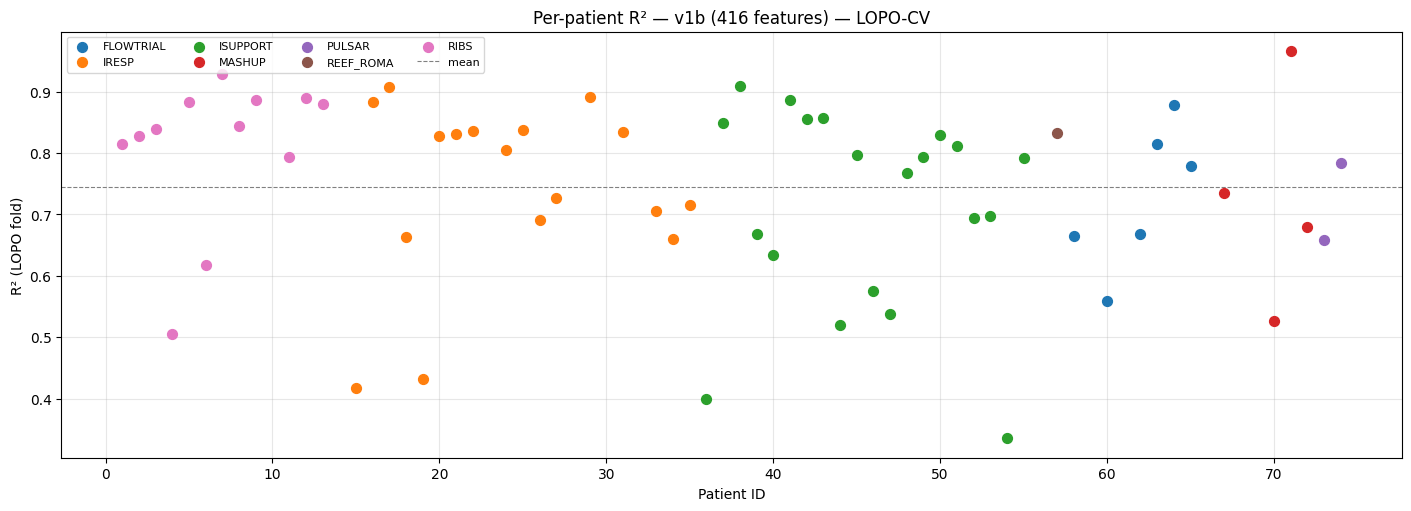

In [8]:
fig, ax = plt.subplots(figsize=(14, 5), layout="constrained")

study_colors = {s: f"C{i}" for i, s in enumerate(studies)}
for study in studies:
    recs = [r for r in results_v1b if r["study"] == study]
    pids = [r["patient_id"] for r in recs]
    r2s = [r["r2"] for r in recs]
    ax.scatter(pids, r2s, c=study_colors[study], label=study, s=50, zorder=3)

ax.axhline(np.mean([r["r2"] for r in results_v1b]), ls="--", c="grey", lw=0.8, label="mean")
ax.set_xlabel("Patient ID")
ax.set_ylabel("R² (LOPO fold)")
ax.set_title("Per-patient R² — v1b (416 features) — LOPO-CV")
ax.legend(ncol=4, fontsize=8)
ax.grid(True, alpha=0.3)
plt.show()

## 7. Global signal overlay (example fold)

The global EIT signal (sum of all pixels) is proportional to tidal volume.
Shown here for the first LOPO fold (held-out patient).

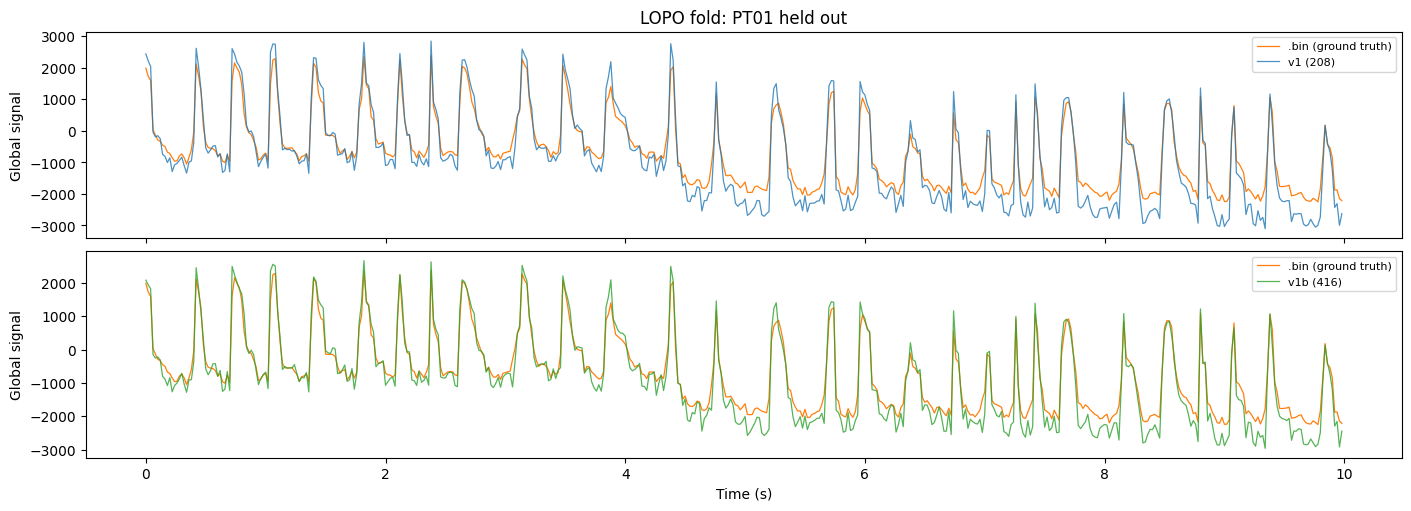

In [9]:
ef = example_fold
g_true = ef["Y_true"].sum(axis=1)
g_v1 = ef["Y_pred_v1"].sum(axis=1)
g_v1b = ef["Y_pred_v1b"].sum(axis=1)

n_show = min(500, len(g_true))
t = np.arange(n_show) / fs

fig, axes = plt.subplots(2, 1, figsize=(14, 5), layout="constrained", sharex=True)

axes[0].plot(t, g_true[:n_show], lw=0.9, label=".bin (ground truth)", color="C1")
axes[0].plot(t, g_v1[:n_show], lw=0.9, label="v1 (208)", color="C0", alpha=0.8)
axes[0].set_ylabel("Global signal")
axes[0].set_title(f"LOPO fold: PT{ef['patient_id']:02d} held out")
axes[0].legend(fontsize=8)

axes[1].plot(t, g_true[:n_show], lw=0.9, label=".bin (ground truth)", color="C1")
axes[1].plot(t, g_v1b[:n_show], lw=0.9, label="v1b (416)", color="C2", alpha=0.8)
axes[1].set_ylabel("Global signal")
axes[1].set_xlabel("Time (s)")
axes[1].legend(fontsize=8)
plt.show()

## 8. Image comparison — inspiratory peak (example fold)

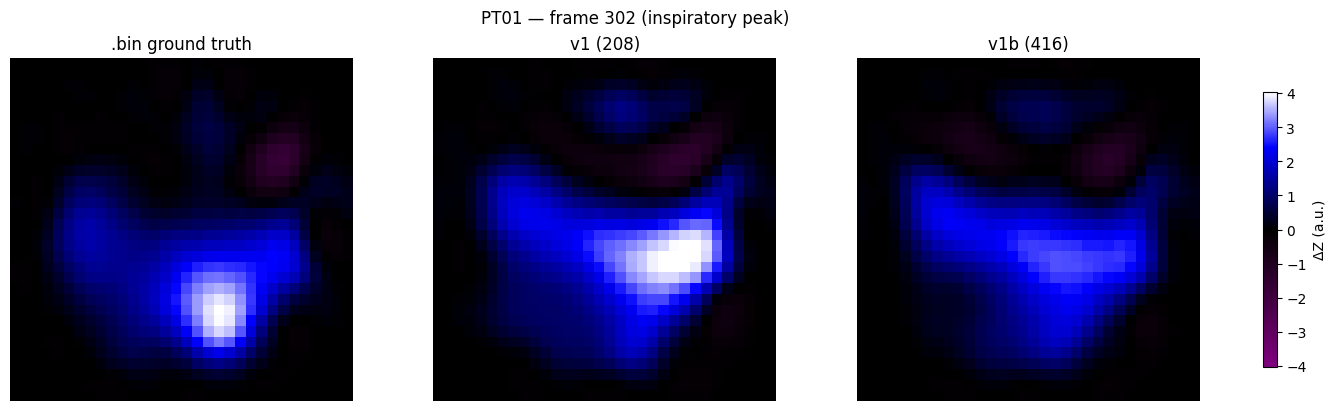

In [10]:
peak_idx = 302

img_true = ef["Y_true"][peak_idx].reshape(32, 32)
img_v1 = ef["Y_pred_v1"][peak_idx].reshape(32, 32)
img_v1b = ef["Y_pred_v1b"][peak_idx].reshape(32, 32)

vmax = max(abs(img_true.min()), abs(img_true.max()))

fig, axes = plt.subplots(1, 3, figsize=(14, 4), layout="constrained")
for ax, img, title in zip(axes, [img_true, img_v1, img_v1b],
                           [".bin ground truth", "v1 (208)", "v1b (416)"]):
    im = ax.imshow(img, cmap=CMAP_EIT, vmin=-vmax, vmax=vmax, origin="lower")
    ax.set_title(title)
    ax.axis("off")
fig.colorbar(im, ax=axes, shrink=0.8, label="ΔZ (a.u.)")
fig.suptitle(f"PT{ef['patient_id']:02d} — frame {peak_idx} (inspiratory peak)", fontsize=12)
plt.show()

## 9. Spatial correlation distribution (all folds)

Spatial correlations collected during the LOPO loop — pooled across all
76 folds into a single histogram.

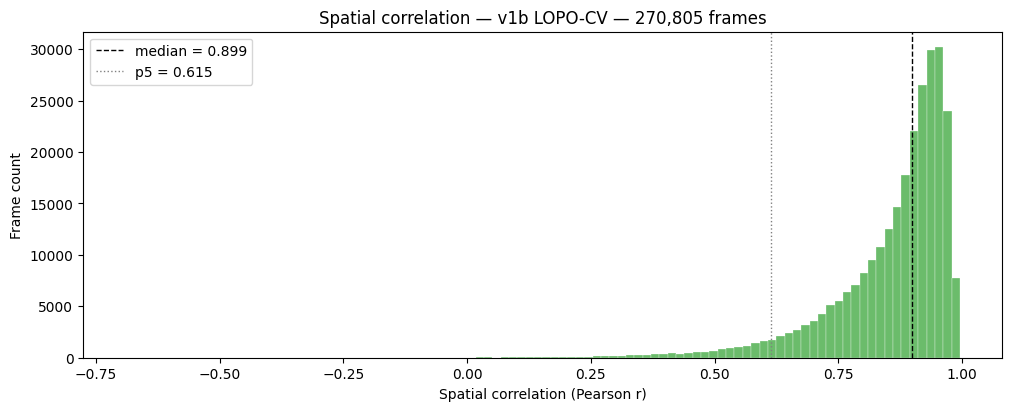

In [11]:
all_corr = np.concatenate(all_corr_v1b)

fig, ax = plt.subplots(figsize=(10, 4), layout="constrained")
ax.hist(all_corr, bins=100, color="C2", alpha=0.7, edgecolor="white", lw=0.3)
ax.axvline(np.median(all_corr), ls="--", color="k", lw=1,
           label=f"median = {np.median(all_corr):.3f}")
ax.axvline(np.percentile(all_corr, 5), ls=":", color="grey", lw=1,
           label=f"p5 = {np.percentile(all_corr, 5):.3f}")
ax.set_xlabel("Spatial correlation (Pearson r)")
ax.set_ylabel("Frame count")
ax.set_title(f"Spatial correlation — v1b LOPO-CV — {len(all_corr):,} frames")
ax.legend()
plt.show()